# 03 · Compuerta de resolución y conectividad — Bogotá 2023

**Objetivo.** Elegir empíricamente la escala espacial principal del modelo estocástico comparando ZAT y UTAM.

La **Compuerta 4** evalúa cobertura de nodos, conectividad dirigida, soporte muestral y efectivo por transición, estabilidad bootstrap y viabilidad de segmentar la red. No calcula todavía accesibilidad a servicios.


In [10]:
%pip -q install pandas geopandas pyarrow networkx matplotlib seaborn


In [11]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import hashlib
import json
import re
import shutil
import unicodedata
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate4"
OUT = ROOT / "outputs/bogota_em2023/gate4"
DRIVE_CACHE_DIR = Path(
    "/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023"
)
for directory in (RAW, INTERIM, OUT):
    directory.mkdir(parents=True, exist_ok=True)

SOURCES = {
    "processed_edoh": {
        "url": "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/05_Base%20datos%20procesada%20EODH.zip",
        "description": "Base procesada EODH 2023",
    },
    "zoning_edoh": {
        "url": "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/03_Zonificacion%20EODH%20%281%29.zip",
        "description": "Zonificación UTAM y ZAT",
    },
}

BOOTSTRAP_REPLICATES = 30
RANDOM_SEED = 202309
print("Workspace:", ROOT)


Workspace: /content/colombia-stochastic-access


## 1. Recuperación reproducible

Se reutilizan los ZIP validados y almacenados en Google Drive por los notebooks anteriores. Si la caché no está disponible, Colab solicitará cada ZIP manualmente.


In [12]:
def sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)


def mount_drive_cache():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
        return DRIVE_CACHE_DIR
    except Exception as exc:
        print(f"No se activó la caché de Drive: {exc}")
        return None


def upload_zip(source_id, source, destination):
    from google.colab import files

    print("\nDESCARGA PRIMERO EN TU NAVEGADOR:")
    print(source["url"])
    print(f"Después selecciona: {source['description']}")
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Suba exactamente un archivo ZIP.")
    uploaded_name, content = next(iter(uploaded.items()))
    temporary = destination.with_suffix(destination.suffix + ".upload")
    temporary.write_bytes(content)
    del content
    if not valid_zip(temporary):
        temporary.unlink(missing_ok=True)
        raise ValueError(f"{uploaded_name} no es un ZIP válido.")
    temporary.replace(destination)
    return "manual_upload"


def ensure_archive(source_id, source, drive_cache):
    destination = RAW / f"{source_id}.zip"
    if valid_zip(destination):
        method = "runtime_cache"
    else:
        cached = drive_cache / destination.name if drive_cache else None
        if cached is not None and valid_zip(cached):
            shutil.copy2(cached, destination)
            method = "google_drive_cache"
            print(f"Recuperado de Drive: {destination.name}")
        else:
            method = upload_zip(source_id, source, destination)
            if drive_cache is not None:
                shutil.copy2(destination, drive_cache / destination.name)
    return {
        "source_id": source_id,
        "url": source["url"],
        "path": str(destination),
        "bytes": int(destination.stat().st_size),
        "sha256": sha256(destination),
        "retrieval_method": method,
    }


def extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    queue = [(Path(zip_path), destination)]
    visited = set()
    while queue:
        current_zip, current_destination = queue.pop(0)
        signature = (str(current_zip.resolve()), str(current_destination.resolve()))
        if signature in visited:
            continue
        visited.add(signature)
        with zipfile.ZipFile(current_zip) as archive:
            archive.extractall(current_destination)
        for nested in current_destination.rglob("*.zip"):
            nested_destination = nested.parent / nested.stem
            nested_signature = (
                str(nested.resolve()),
                str(nested_destination.resolve()),
            )
            if nested_signature not in visited:
                queue.append((nested, nested_destination))


drive_cache = mount_drive_cache()
manifest = pd.DataFrame([
    ensure_archive(source_id, source, drive_cache)
    for source_id, source in SOURCES.items()
])
for row in manifest.itertuples(index=False):
    extract_recursive(Path(row.path), INTERIM / row.source_id)

manifest["generated_utc"] = datetime.now(timezone.utc).isoformat()
manifest.to_csv(OUT / "source_manifest.csv", index=False)
display(manifest)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,source_id,url,path,bytes,sha256,retrieval_method,generated_utc
0,processed_edoh,https://observatorio.movilidadbogota.gov.co/si...,/content/colombia-stochastic-access/data/raw/b...,88826883,2509410f39713de4768872952e75e95809a99d7edf5b65...,runtime_cache,2026-09-10T20:31:44.293328+00:00
1,zoning_edoh,https://observatorio.movilidadbogota.gov.co/si...,/content/colombia-stochastic-access/data/raw/b...,12225582,405ef62643663e656f58b0595a90a873029809e0aab430...,runtime_cache,2026-09-10T20:31:44.293328+00:00


## 2. Viajes y escalas oficiales

Se cargan únicamente las variables requeridas. Los códigos espaciales se mantienen como texto y los ponderadores se convierten respetando separadores decimales locales.


In [13]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(
        char for char in value if not unicodedata.combining(char)
    )
    value = value.lower().strip()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    return value.strip("_")


def clean_key(series):
    cleaned = series.astype("string").str.strip()
    cleaned = cleaned.str.replace(r"\.0$", "", regex=True)
    invalid = cleaned.map(normalize).isin(
        ["", "nan", "none", "na", "no_aplica", "sin_informacion"]
    )
    return cleaned.mask(invalid)


def canonical_utam(series):
    """Unifica 1, 001 y UTAM001; conserva códigos rurales UPR."""
    cleaned = clean_key(series)

    def canonical(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper().replace(" ", "")

        upr_match = re.fullmatch(r"UPR0*(\d+)", text)
        if upr_match:
            return f"UPR{int(upr_match.group(1)):04d}"

        utam_match = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        if utam_match:
            return f"UTAM{int(utam_match.group(1)):03d}"

        return text

    return cleaned.map(canonical).astype("string")


def parse_number(series):
    raw = series.astype("string").str.strip()
    comma_share = float(raw.str.contains(",", regex=False, na=False).mean())
    if comma_share > 0.05:
        raw = raw.str.replace(".", "", regex=False)
        raw = raw.str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")


def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle:
                sample = handle.read(32768)
            delimiter = csv.Sniffer().sniff(
                sample, delimiters=",;\t|"
            ).delimiter
            return encoding, delimiter
        except (UnicodeDecodeError, csv.Error):
            continue
    raise ValueError(f"No fue posible detectar formato: {path}")


def read_selected(path, desired):
    encoding, delimiter = csv_format(path)
    header = pd.read_csv(path, sep=delimiter, encoding=encoding, nrows=0)
    mapping = {normalize(column): column for column in header.columns}
    missing = sorted(set(desired) - set(mapping))
    if missing:
        raise KeyError(f"Columnas ausentes en {path.name}: {missing}")
    frame = pd.read_csv(
        path,
        sep=delimiter,
        encoding=encoding,
        usecols=[mapping[column] for column in desired],
        dtype="string",
        low_memory=False,
    )
    frame.columns = [normalize(column) for column in frame.columns]
    return frame


csv_paths = list((INTERIM / "processed_edoh").rglob("*.csv"))
trip_paths = [
    path for path in csv_paths
    if "viaje" in normalize(path.stem)
    and "etapa" not in normalize(path.stem)
]
if not trip_paths:
    raise FileNotFoundError("No se encontró el módulo de viajes CSV.")
trip_path = sorted(trip_paths, key=lambda path: len(path.parts))[0]

desired_columns = [
    "fexp_vj", "zat_ori", "zat_des", "utam_ori", "utam_des",
    "modo_principal_agrupado", "hora_ini", "sexo", "genero",
    "estra_hg", "nom_mun_ori", "nom_mun_des",
]
trips = read_selected(trip_path, desired_columns)

for column in ("zat_ori", "zat_des"):
    trips[column] = clean_key(trips[column])
for column in ("utam_ori", "utam_des"):
    trips[column] = canonical_utam(trips[column])
trips["weight"] = parse_number(trips["fexp_vj"])
trips = trips[trips["weight"].gt(0)].copy()

def official_codes(scale):
    token = scale.lower()
    candidates = [
        path for path in (INTERIM / "zoning_edoh").rglob("*.shp")
        if token in normalize(path.stem)
    ]
    if not candidates:
        raise FileNotFoundError(f"No se encontró shapefile {scale}.")
    layer = gpd.read_file(sorted(candidates, key=lambda path: len(path.parts))[0])
    mapping = {normalize(column): column for column in layer.columns}
    if token not in mapping:
        raise KeyError(f"La capa {scale} no contiene el código {scale}.")
    codes = (
        canonical_utam(layer[mapping[token]])
        if token == "utam"
        else clean_key(layer[mapping[token]])
    )
    return set(codes.dropna().unique()), layer

official_zat, zat_layer = official_codes("zat")
official_utam, utam_layer = official_codes("utam")
print(f"Viajes válidos: {len(trips):,}")
print(f"ZAT oficiales: {len(official_zat):,}")
print(f"UTAM oficiales: {len(official_utam):,}")
observed_utam = set(trips["utam_ori"].dropna()) | set(
    trips["utam_des"].dropna()
)
print(f"UTAM observadas: {len(observed_utam):,}")
print(
    "Coincidencia UTAM:",
    f"{len(observed_utam & official_utam)}/{len(official_utam)}",
)
if observed_utam - official_utam:
    print(
        "Códigos observados no cartografiados:",
        sorted(observed_utam - official_utam)[:20],
    )


Viajes válidos: 100,174
ZAT oficiales: 1,215
UTAM oficiales: 142
UTAM observadas: 141
Coincidencia UTAM: 140/142
Códigos observados no cartografiados: ['UTAM063']


## 3. Matrices de transición y conectividad

Para cada escala se construye una red dirigida ponderada. Las aristas incluyen viajes muestrales, viajes expandidos, tamaño efectivo de Kish y probabilidad de transición condicionada al origen.


In [14]:
def build_edges(frame, origin, destination):
    working = frame[[origin, destination, "weight"]].dropna().copy()
    working["weight_sq"] = working["weight"] ** 2
    edges = (
        working.groupby([origin, destination], observed=True)
        .agg(
            sampled_trips=("weight", "size"),
            weighted_trips=("weight", "sum"),
            sum_weight_sq=("weight_sq", "sum"),
        )
        .reset_index()
    )
    edges["effective_sample_size"] = (
        edges["weighted_trips"] ** 2
        / edges["sum_weight_sq"].replace(0, np.nan)
    )
    outflow = edges.groupby(origin)["weighted_trips"].transform("sum")
    edges["transition_probability"] = edges["weighted_trips"] / outflow
    return edges.drop(columns="sum_weight_sq")


def network_metrics(edges, origin, destination, official, scale):
    observed = set(edges[origin]) | set(edges[destination])
    graph = nx.DiGraph()
    graph.add_nodes_from(observed)
    graph.add_edges_from(edges[[origin, destination]].itertuples(index=False, name=None))

    strong = list(nx.strongly_connected_components(graph))
    weak = list(nx.weakly_connected_components(graph))
    largest_strong = max((len(component) for component in strong), default=0)
    largest_weak = max((len(component) for component in weak), default=0)
    denominator = len(observed) * max(len(observed) - 1, 1)

    total_weight = float(edges["weighted_trips"].sum())
    self_mask = edges[origin].eq(edges[destination])
    origins = set(edges[origin])
    destinations = set(edges[destination])

    origin_entropy = (
        edges.assign(
            entropy_term=-edges["transition_probability"]
            * np.log(edges["transition_probability"])
        )
        .groupby(origin)
        .agg(
            entropy=("entropy_term", "sum"),
            outflow=("weighted_trips", "sum"),
        )
    )
    mean_entropy = float(
        np.average(origin_entropy["entropy"], weights=origin_entropy["outflow"])
    )

    return {
        "scale": scale,
        "official_nodes": int(len(official)),
        "observed_nodes": int(len(observed)),
        "observed_node_coverage": float(len(observed & official) / len(official)),
        "edges": int(len(edges)),
        "self_loops": int(self_mask.sum()),
        "directed_density": float((len(edges) - self_mask.sum()) / denominator),
        "largest_scc_nodes": int(largest_strong),
        "largest_scc_share_observed": float(
            largest_strong / len(observed) if observed else 0
        ),
        "largest_wcc_share_observed": float(
            largest_weak / len(observed) if observed else 0
        ),
        "destination_only_node_share": float(
            len(destinations - origins) / len(observed) if observed else 0
        ),
        "weighted_self_loop_share": float(
            edges.loc[self_mask, "weighted_trips"].sum() / total_weight
        ),
        "median_edge_sample": float(edges["sampled_trips"].median()),
        "median_edge_ess": float(edges["effective_sample_size"].median()),
        "weighted_support_n5_share": float(
            edges.loc[edges["sampled_trips"].ge(5), "weighted_trips"].sum()
            / total_weight
        ),
        "weighted_support_ess5_share": float(
            edges.loc[
                edges["effective_sample_size"].ge(5), "weighted_trips"
            ].sum()
            / total_weight
        ),
        "mean_origin_entropy": mean_entropy,
    }


scale_spec = {
    "ZAT": ("zat_ori", "zat_des", official_zat),
    "UTAM": ("utam_ori", "utam_des", official_utam),
}
edge_tables = {}
metric_rows = []
for scale, (origin, destination, official) in scale_spec.items():
    edges = build_edges(trips, origin, destination)
    edge_tables[scale] = edges
    metric_rows.append(
        network_metrics(edges, origin, destination, official, scale)
    )
    edges.to_parquet(
        OUT / f"transition_edges_{scale.lower()}.parquet", index=False
    )

resolution_metrics = pd.DataFrame(metric_rows).set_index("scale")
resolution_metrics.to_csv(OUT / "resolution_metrics.csv")
display(resolution_metrics.T)


scale,ZAT,UTAM
official_nodes,1215.000000,142.000000
observed_nodes,1162.000000,141.000000
observed_node_coverage,0.956379,0.985915
edges,47469.000000,12408.000000
self_loops,597.000000,140.000000
directed_density,0.034744,0.621479
largest_scc_nodes,1153.000000,141.000000
largest_scc_share_observed,0.992255,1.000000
largest_wcc_share_observed,1.000000,1.000000
destination_only_node_share,0.005164,0.000000


## 4. Comparación gráfica

Las métricas se expresan en porcentaje cuando su rango natural es de cero a uno. La figura no sustituye la tabla completa.


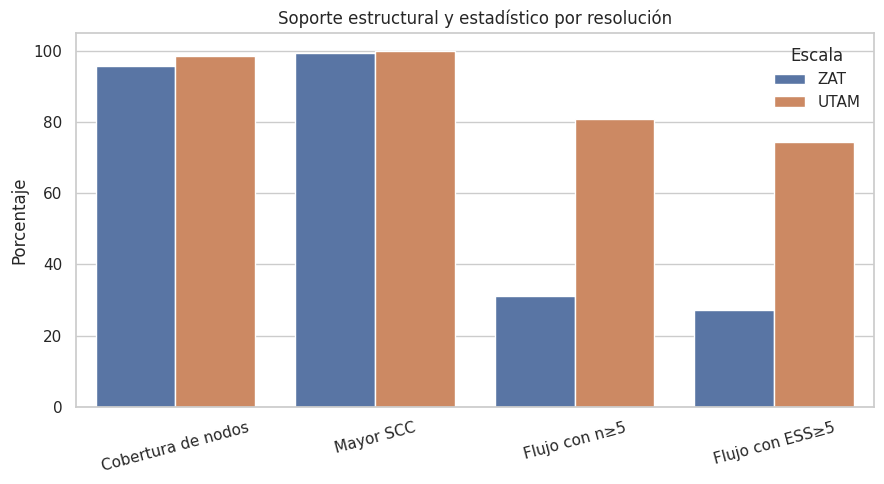

In [15]:
plot_metrics = resolution_metrics[
    [
        "observed_node_coverage",
        "largest_scc_share_observed",
        "weighted_support_n5_share",
        "weighted_support_ess5_share",
    ]
].mul(100).rename(columns={
    "observed_node_coverage": "Cobertura de nodos",
    "largest_scc_share_observed": "Mayor SCC",
    "weighted_support_n5_share": "Flujo con n≥5",
    "weighted_support_ess5_share": "Flujo con ESS≥5",
})

plot_long = (
    plot_metrics.reset_index()
    .melt(id_vars="scale", var_name="Métrica", value_name="Porcentaje")
)
sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=plot_long,
    x="Métrica",
    y="Porcentaje",
    hue="scale",
    ax=ax,
)
ax.set_ylim(0, 105)
ax.set_xlabel("")
ax.set_ylabel("Porcentaje")
ax.set_title("Soporte estructural y estadístico por resolución")
ax.legend(title="Escala", frameon=False)
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(OUT / "resolution_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Estabilidad bootstrap

Se usa bootstrap de Poisson sobre los viajes. Para las aristas con al menos cinco observaciones se compara la probabilidad remuestreada con la matriz original mediante error absoluto ponderado por flujo.


In [16]:
def bootstrap_stability(
    frame,
    origin,
    destination,
    base_edges,
    replicates=30,
    seed=202309,
):
    valid = frame[[origin, destination, "weight"]].dropna().reset_index(drop=True)
    core = base_edges[base_edges["sampled_trips"].ge(5)].copy()
    core_index = pd.MultiIndex.from_frame(core[[origin, destination]])
    base_probability = core["transition_probability"].to_numpy()
    importance = core["weighted_trips"].to_numpy()
    importance = importance / importance.sum()

    rng = np.random.default_rng(seed)
    rows = []
    for replicate in range(replicates):
        multiplicity = rng.poisson(1, len(valid))
        bootstrap_weight = valid["weight"].to_numpy() * multiplicity
        boot = valid.assign(bootstrap_weight=bootstrap_weight)
        boot_edges = (
            boot.groupby([origin, destination], observed=True)[
                "bootstrap_weight"
            ]
            .sum()
            .rename("weighted_trips")
            .reset_index()
        )
        boot_edges["outflow"] = boot_edges.groupby(origin)[
            "weighted_trips"
        ].transform("sum")
        boot_edges["probability"] = (
            boot_edges["weighted_trips"]
            / boot_edges["outflow"].replace(0, np.nan)
        )
        boot_series = boot_edges.set_index([origin, destination])[
            "probability"
        ]
        aligned = boot_series.reindex(core_index).fillna(0).to_numpy()
        absolute_error = np.abs(aligned - base_probability)
        rows.append({
            "replicate": replicate + 1,
            "weighted_mae": float(np.sum(importance * absolute_error)),
            "median_absolute_error": float(np.median(absolute_error)),
            "p95_absolute_error": float(np.quantile(absolute_error, 0.95)),
        })
    return pd.DataFrame(rows)


bootstrap_frames = []
for offset, (scale, spec) in enumerate(scale_spec.items()):
    origin, destination, _ = spec
    result = bootstrap_stability(
        trips,
        origin,
        destination,
        edge_tables[scale],
        replicates=BOOTSTRAP_REPLICATES,
        seed=RANDOM_SEED + offset,
    )
    result.insert(0, "scale", scale)
    bootstrap_frames.append(result)

bootstrap_results = pd.concat(bootstrap_frames, ignore_index=True)
bootstrap_results.to_csv(OUT / "bootstrap_stability.csv", index=False)
bootstrap_summary = (
    bootstrap_results.groupby("scale")
    .agg(
        median_weighted_mae=("weighted_mae", "median"),
        p95_weighted_mae=("weighted_mae", lambda x: x.quantile(0.95)),
        median_edge_mae=("median_absolute_error", "median"),
        median_p95_edge_error=("p95_absolute_error", "median"),
    )
)
bootstrap_summary.to_csv(OUT / "bootstrap_summary.csv")
display(bootstrap_summary)


,median_weighted_mae,p95_weighted_mae,median_edge_mae,median_p95_edge_error
scale,,,,
UTAM,0.009740,0.010292,0.002582,0.01574
ZAT,0.025323,0.026423,0.008706,0.06754


## 6. Viabilidad de segmentaciones sobre UTAM

Se diagnostican franjas horarias, modo, sexo y estrato. Una categoría se considera viable para una red separada si conserva suficiente tamaño, cobertura, conectividad y flujo sobre aristas con soporte.


In [17]:
def extract_hour(series):
    text = series.astype("string").str.strip()
    colon_hour = pd.to_numeric(
        text.str.extract(r"^(\d{1,2}):", expand=False),
        errors="coerce",
    )
    numeric = parse_number(text)
    numeric_hour = pd.Series(np.nan, index=series.index, dtype=float)

    fractional = numeric.between(0, 1, inclusive="left")
    numeric_hour.loc[fractional] = np.floor(numeric.loc[fractional] * 24)

    direct = numeric.between(1, 23.999)
    numeric_hour.loc[direct] = np.floor(numeric.loc[direct])

    hhmm = numeric.between(100, 2359)
    possible_hhmm = np.floor(numeric.loc[hhmm] / 100)
    possible_minutes = np.floor(numeric.loc[hhmm] / 60)
    numeric_hour.loc[hhmm] = np.where(
        (numeric.loc[hhmm] % 100) < 60,
        possible_hhmm,
        possible_minutes,
    )
    return colon_hour.fillna(numeric_hour).where(lambda x: x.between(0, 23))


trips["hour"] = extract_hour(trips["hora_ini"])
trips["time_band"] = pd.cut(
    trips["hour"],
    bins=[-0.1, 5.999, 8.999, 15.999, 18.999, 23.999],
    labels=["Madrugada", "Pico AM", "Valle diurno", "Pico PM", "Noche"],
)
trips["mode_group"] = trips["modo_principal_agrupado"].astype("string").str.strip()
trips["sex_group"] = trips["sexo"].astype("string").str.strip()
trips["stratum_group"] = clean_key(trips["estra_hg"])

segment_dimensions = {
    "time_band": "time_band",
    "mode": "mode_group",
    "sex": "sex_group",
    "stratum": "stratum_group",
}
segment_rows = []
for dimension, column in segment_dimensions.items():
    for level, subset in trips.dropna(subset=[column]).groupby(
        column, observed=True
    ):
        if len(subset) < 100:
            continue
        edges = build_edges(subset, "utam_ori", "utam_des")
        metrics = network_metrics(
            edges,
            "utam_ori",
            "utam_des",
            official_utam,
            "UTAM",
        )
        viable = (
            len(subset) >= 500
            and metrics["observed_node_coverage"] >= 0.50
            and metrics["largest_scc_share_observed"] >= 0.40
            and metrics["weighted_support_n5_share"] >= 0.60
        )
        segment_rows.append({
            "dimension": dimension,
            "level": str(level),
            "sampled_trips": int(len(subset)),
            "weighted_trips": float(subset["weight"].sum()),
            "observed_node_coverage": metrics["observed_node_coverage"],
            "largest_scc_share_observed": metrics[
                "largest_scc_share_observed"
            ],
            "weighted_support_n5_share": metrics[
                "weighted_support_n5_share"
            ],
            "viable_separate_kernel": bool(viable),
        })

segmentation = pd.DataFrame(segment_rows)
segmentation.to_csv(OUT / "segmentation_feasibility.csv", index=False)
display(
    segmentation.sort_values(
        ["dimension", "weighted_trips"], ascending=[True, False]
    )
)


,dimension,level,sampled_trips,weighted_trips,observed_node_coverage,largest_scc_share_observed,weighted_support_n5_share,viable_separate_kernel
15,mode,TRANSPORTE PÚBLICO,29407,4923922.6,0.985915,1.000000,0.462914,False
6,mode,A PIE > 15 MIN,24932,4101175.4,0.985915,0.992857,0.864981,True
5,mode,A PIE <15 MIN,12392,2105820.2,0.985915,0.942857,0.853287,True
7,mode,AUTO,12586,1973720.1,0.985915,1.000000,0.425179,False
8,mode,BICICLETA,6104,1161157.9,0.985915,0.985816,0.427991,False
11,mode,MOTO,6247,1084670.3,0.985915,1.000000,0.136234,False
13,mode,TAXI OCUPADO,3267,561807.8,0.978873,0.913669,0.255525,False
14,mode,TRANSPORTE ESCOLAR,2058,300495.3,0.971831,0.942029,0.235506,False
9,mode,ESPECIAL OCUPADO,1982,295209.5,0.978873,0.956835,0.175296,False
10,mode,INFORMAL,867,162872.3,0.880282,0.776000,0.284551,False


## 7. Compuerta 4 y recomendación

La recomendación combina estructura, soporte estadístico y estabilidad. Los umbrales se registran explícitamente para evitar seleccionar la escala después de observar resultados sustantivos.


In [18]:
thresholds = {
    "observed_node_coverage_min": 0.80,
    "largest_scc_share_min": 0.75,
    "weighted_support_n5_min": 0.75,
    "weighted_support_ess5_min": 0.70,
    "bootstrap_median_weighted_mae_max": 0.08,
}

decision = resolution_metrics.join(bootstrap_summary)
decision["stability_score"] = (
    1 - decision["median_weighted_mae"] / 0.10
).clip(0, 1)
decision["resolution_score"] = (
    0.20 * decision["observed_node_coverage"].clip(0, 1)
    + 0.30 * decision["largest_scc_share_observed"].clip(0, 1)
    + 0.20 * decision["weighted_support_n5_share"].clip(0, 1)
    + 0.15 * decision["weighted_support_ess5_share"].clip(0, 1)
    + 0.15 * decision["stability_score"]
)
decision["passes_core_thresholds"] = (
    decision["observed_node_coverage"].ge(
        thresholds["observed_node_coverage_min"]
    )
    & decision["largest_scc_share_observed"].ge(
        thresholds["largest_scc_share_min"]
    )
    & decision["weighted_support_n5_share"].ge(
        thresholds["weighted_support_n5_min"]
    )
    & decision["weighted_support_ess5_share"].ge(
        thresholds["weighted_support_ess5_min"]
    )
    & decision["median_weighted_mae"].le(
        thresholds["bootstrap_median_weighted_mae_max"]
    )
)

eligible = decision[decision["passes_core_thresholds"]]
ranking_pool = eligible if not eligible.empty else decision
recommended_resolution = str(
    ranking_pool["resolution_score"].idxmax()
)
gate4 = {
    "at_least_one_resolution_passes": bool(
        decision["passes_core_thresholds"].any()
    ),
    "recommended_resolution": recommended_resolution,
    "gate_4_passed": bool(
        decision["passes_core_thresholds"].any()
    ),
}

segment_coverage = {}
for dimension, group in segmentation.groupby("dimension"):
    total = group["weighted_trips"].sum()
    viable_weight = group.loc[
        group["viable_separate_kernel"], "weighted_trips"
    ].sum()
    segment_coverage[dimension] = float(
        viable_weight / total if total else 0
    )

decision.to_csv(OUT / "resolution_decision.csv")
report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "bootstrap_replicates": int(BOOTSTRAP_REPLICATES),
    "random_seed": int(RANDOM_SEED),
    "thresholds": {key: float(value) for key, value in thresholds.items()},
    "recommended_resolution": recommended_resolution,
    "gate": gate4,
    "segment_weight_coverage": segment_coverage,
    "decision": json.loads(
        decision.reset_index().to_json(orient="records")
    ),
}
(OUT / "gate_4.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)

display(decision[[
    "resolution_score",
    "passes_core_thresholds",
    "observed_node_coverage",
    "largest_scc_share_observed",
    "weighted_support_n5_share",
    "weighted_support_ess5_share",
    "median_weighted_mae",
]])
print(json.dumps(gate4, ensure_ascii=False, indent=2))
print("Cobertura ponderada de categorías viables:")
display(pd.Series(segment_coverage, name="coverage"))
if drive_cache is not None:
    persistent_out = drive_cache / "results/gate4"
    persistent_out.mkdir(parents=True, exist_ok=True)
    for artifact in OUT.iterdir():
        if artifact.is_file():
            shutil.copy2(artifact, persistent_out / artifact.name)
    print("Copia persistente:", persistent_out)

print("Resultados:", OUT)


,resolution_score,passes_core_thresholds,observed_node_coverage,largest_scc_share_observed,weighted_support_n5_share,weighted_support_ess5_share,median_weighted_mae
scale,,,,,,,
ZAT,0.704241,False,0.956379,0.992255,0.312075,0.272392,0.025323
UTAM,0.905709,True,0.985915,1.000000,0.806961,0.744956,0.009740


{
  "at_least_one_resolution_passes": true,
  "recommended_resolution": "UTAM",
  "gate_4_passed": true
}
Cobertura ponderada de categorías viables:


,coverage
mode,0.371164
sex,1.000000
stratum,0.918612
time_band,0.675435


Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate4
Resultados: /content/colombia-stochastic-access/outputs/bogota_em2023/gate4


## Interpretación

- Si la recomendación es UTAM, se utilizará como escala inferencial principal y ZAT quedará para sensibilidad espacial y cartografía.
- Si ZAT también supera los umbrales, puede emplearse como análisis no segmentado o con regularización.
- Las categorías marcadas como no viables no deben recibir una matriz independiente sin agrupación, suavizado jerárquico o información adicional.
- El siguiente notebook construirá los kernels temporales y de grupo únicamente después de aceptar esta compuerta.
